In [228]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from dataclasses import dataclass, field
from typing import Optional

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [229]:
#  Setup
import os, sys
import numpy as np
import pandas as pd
from ast import literal_eval

sys.path.append(os.path.dirname(os.getcwd()))

from swp.utils.setup import seed_everything, set_device
from swp.utils.models import get_model
from swp.datasets.phonemes import get_phoneme_to_id

seed_everything(42)
device = set_device()



Using MPS device


Interventions on phoneme type or position

two sequences: for each original sequence y, create two sequences base and source 
based on type: consonant or vowel

if type is consonant
base is created from y keep the c but replace vowels with random other vowels
source replace consonants and keep original vowels
the goal is to replace consonants of source with base and get the original seq

similar for vowel

In [230]:
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
model = get_model(model_name)
import torch
model.load_state_dict(torch.load("../reproduce/weights/2048_75.pth", map_location=device, weights_only=True))
model.to(device)
model.eval()

phoneme_to_id = get_phoneme_to_id()
id_to_phoneme = {v: k for k, v in phoneme_to_id.items()}

ph_features = pd.read_csv("datasets/phonemes.csv")

vowels = ph_features[ph_features["Type"] == "V"]["Phoneme"].tolist()
consonants = ph_features[ph_features["Type"] == "C"]["Phoneme"].tolist()

vowel_ids = [phoneme_to_id[ph] for ph in vowels if ph in phoneme_to_id]
consonant_ids = [phoneme_to_id[ph] for ph in consonants if ph in phoneme_to_id]

# Constants
PAD_ID = phoneme_to_id["<PAD>"]
EOS_ID = phoneme_to_id["<EOS>"]
SOS_ID = phoneme_to_id["<SOS>"]


In [231]:
# from swp.utils.datasets import get_train_dataset
# train_df = get_train_dataset()
# train_df.tail()

In [232]:
test_df = pd.read_csv("datasets/wfe.csv")
test_df.head()

,Unnamed: 0,Word,Condition,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Phonemes,No_Stress,Part of Speech,Vowel Count,Consonant Count
0,0,attending,RLCH,real,long,complex,0.000020,7,4.31,"['AH0', 'T', 'EH1', 'N', 'D', 'IH0', 'NG']","['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']",VERB,3,4
1,1,commissioner,RLCH,real,long,complex,0.000027,8,4.43,"['K', 'AH0', 'M', 'IH1', 'SH', 'AH0', 'N', 'ER0']","['K', 'AH', 'M', 'IH', 'SH', 'AH', 'N', 'ER']",NOUN,4,4
2,2,operation,RLCH,real,long,complex,0.000083,7,4.92,"['AA2', 'P', 'ER0', 'EY1', 'SH', 'AH0', 'N']","['AA', 'P', 'ER', 'EY', 'SH', 'AH', 'N']",NOUN,4,3
3,3,hospitals,RLCH,real,long,complex,0.000021,9,4.33,"['HH', 'AA1', 'S', 'P', 'IH2', 'T', 'AH0', 'L'...","['HH', 'AA', 'S', 'P', 'IH', 'T', 'AH', 'L', 'Z']",NOUN,3,6
4,4,acquisition,RLCH,real,long,complex,0.000018,9,4.26,"['AE2', 'K', 'W', 'AH0', 'Z', 'IH1', 'SH', 'AH...","['AE', 'K', 'W', 'AH', 'Z', 'IH', 'SH', 'AH', ...",NOUN,4,5


In [233]:

import random


class InterventionDataset(Dataset):
    """Dataset for training the intervention model.
    base is replaced by source where the phoneme is the same as intervention type to get the original sequence."""
    
    def __init__(self, sequences: list, phoneme_to_id: dict, vowel_ids: list, consonant_ids: list,
                 pad_id: int, sos_id: int, eos_id: int, max_len: int):
        self.sequences = sequences
        self.phoneme_to_id = phoneme_to_id
        self.vowel_ids = vowel_ids
        self.consonant_ids = consonant_ids
        self.pad_id = pad_id
        self.sos_id = sos_id
        self.eos_id = eos_id
        self.max_len = max_len
        self.special_ids = [pad_id, sos_id, eos_id]
        self.intervention_list = self.intervention_list()
        self.no_intervention = False

  
    
    def __len__(self):
        return len(self.sequences)
    
    def intervention_list(self):
        interventions = ['consonant'] * (len(self.sequences) // 2) + ['vowel'] * (len(self.sequences) - (len(self.sequences) // 2))
        random.shuffle(interventions)
        return interventions  
    
    def pad_sequence(self, seq):
        """Add SOS and EOS tokens, and pad to max_len"""
        seq =  list(seq) + [self.eos_id]
        if len(seq) < self.max_len:
            seq += [self.pad_id] * (self.max_len - len(seq))
        else:
            seq = seq[:self.max_len-1] + [self.eos_id]  # Truncate and add EOS 
        return torch.tensor(seq, dtype=torch.long)
        
    def _type_intervention(self, original_seq, intervention_type):
        """crete source and base sequences based on the intervention type
        intervention_type can be "consonant" or "vowel"
        replacing the consonant/vowel in source with the consonant/vowel in base result in the original sequence
        """
        if intervention_type == "consonant":
            # example original: NaFiS, base: GaZiN, source: NeFoS
            base_seq = np.array([ph if ph in self.vowel_ids else np.random.choice(self.consonant_ids) for ph in original_seq])
            source_seq = np.array([ph if ph in self.consonant_ids else np.random.choice(self.vowel_ids) for ph in original_seq])
        elif intervention_type == "vowel":
            # example original: nAfIs, base: nUfEs, source: bAsOd
            base_seq = np.array([ph if ph in self.consonant_ids else np.random.choice(self.vowel_ids) for ph in original_seq])
            source_seq = np.array([ph if ph in self.vowel_ids else np.random.choice(self.consonant_ids) for ph in original_seq])
        
        if self.no_intervention:
            base_seq = original_seq.copy()
            source_seq = original_seq.copy()

        
        return source_seq, base_seq
    def print_phonemes(self, seq):
        return [id_to_phoneme[id.item()] for id in seq if id.item() not in self.special_ids]
    def __getitem__(self, idx, intervention_type=None):
        original_seq = self.sequences[idx].copy()
        seq_len = len(original_seq)
        if intervention_type is None:
            intervention_type = self.intervention_list[idx]
            
   
        source_seq, base_seq = self._type_intervention(original_seq, intervention_type)

        source_seq = self.pad_sequence(source_seq)
        base_seq = self.pad_sequence(base_seq)
        original_seq = self.pad_sequence(original_seq)

        return {
            "original": original_seq,
            "source": source_seq,
            "base": base_seq,
            "intervention_type": intervention_type,
            "seq_len": torch.tensor(seq_len, dtype=torch.long),
        
        }



In [234]:
special_ids = [PAD_ID, SOS_ID, EOS_ID]
#
seq = literal_eval(test_df["No_Stress"].loc[0])
test_seq = [phoneme_to_id[ph] for ph in seq]
dataset = InterventionDataset(sequences=[test_seq], phoneme_to_id=phoneme_to_id, vowel_ids=vowel_ids, consonant_ids=consonant_ids,
                              pad_id=PAD_ID, sos_id=SOS_ID, eos_id=EOS_ID, max_len=20)
print(seq)
print(test_seq)
sample = dataset[0]
print("Original:", dataset.print_phonemes(sample["original"]))
print("Base:", dataset.print_phonemes(sample["base"]))
print("Source:", dataset.print_phonemes(sample["source"]))
sample


['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']
[5, 33, 13, 25, 11, 19, 26]
Original: ['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']
Base: ['UW', 'T', 'AY', 'N', 'D', 'OW', 'NG']
Source: ['AH', 'HH', 'EH', 'Z', 'TH', 'IH', 'L']


{'original': tensor([ 5, 33, 13, 25, 11, 19, 26,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0]),
 'source': tensor([ 5, 18, 13, 40, 34, 19, 23,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0]),
 'base': tensor([36, 33,  8, 25, 11, 27, 26,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0]),
 'intervention_type': 'vowel',
 'seq_len': tensor(7)}

In [235]:
class Intervention_DAS(torch.nn.Module):
    """Distributed Alignment Search intervention model.
    
    Learns:
        - rotation: orthogonal (hidden_size, hidden_size) — rotates to semantic space
        - alignment: (hidden_size, n_variables + 1) — assigns each dim to a variable or "none"
        """
    def __init__(self, hidden_size: int, n_variables: int= 2, reg_weight: float=0.001):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_variables = n_variables # number of variables to intervene on (e.g., consonant and vowel)
        self.reg_weight = reg_weight

        self.VARIABLE_NAMES = ["consonant", "vowel"]  

        self.rotation_matrix = torch.nn.utils.parametrizations.orthogonal(
            nn.Linear(hidden_size, hidden_size, bias=False),
            orthogonal_map="cayley")
        
        self.alignment_logits = torch.nn.Parameter(torch.randn(hidden_size, n_variables+1) * 0.01)

    def get_alignment_mask(self):
        """returns hard alignment mask"""
        if self.training:
            return F.gumbel_softmax(self.alignment_logits, tau=1.0 , hard=True)  
        else:
            return F.one_hot(self.alignment_logits.argmax(dim=-1), 
                             num_classes=self.n_variables+1).float()
        
    def get_reg_loss(self):
        """Regularization: penalize assigning too many dims to variables (encourage sparsity)."""
        # Softmax gives probability of each assignment; penalize probability mass on variables
        probs = F.softmax(self.alignment_logits, dim=-1)  # [hidden, n_var+1]
        # Mean probability assigned to any variable (not "neither")
        return self.reg_weight * probs[:, :-1].sum(dim=-1).mean()
    
    def intervene(self, h_base, h_source, var_idx):
        """replace var_idx in h_base with variable_idx in h_source, using alignment mask, var_idx: (0=consonant, 1=vowel)"""
        r_base = self.rotation_matrix(h_base)  # [batch, hidden]
        r_source = self.rotation_matrix(h_source)  # [batch, hidden]

        #get alignment mask
        alignment_mask = self.get_alignment_mask()  # [hidden, n_var+1]
        var_mask = alignment_mask[:, var_idx]  # [hidden]

        # swap: replace base with source where var_mask is 1, keep base where var_mask is 0
        h_patched =  var_mask * r_source + (1 - var_mask) * r_base  # [batch, hidden]

        # rotate back
        h_mod = F.linear(h_patched, self.rotation_matrix.weight.t())  # [batch, hidden]
    
        return h_mod
    def forward(self, h_base, h_source, var_idx):
        h_mod = self.intervene(h_base, h_source, var_idx)
        return h_mod
    
        # ── inspection helpers (used in plot_alignment / training cell) ──────────
    def get_variable_assignment(self) -> torch.Tensor:
        """Returns [hidden_size] with the argmax variable index per dimension."""
        return self.alignment_logits.argmax(-1)

    def get_variable_sizes(self) -> dict:
        """How many hidden dims are assigned to each variable."""
        assignment = self.get_variable_assignment()
        names = self.VARIABLE_NAMES[:self.n_variables] + ["neither"]
        return {name: (assignment == i).sum().item() for i, name in enumerate(names)}

        
        

In [274]:
class InterventionLSTM:
    """Wraps a frozen encoder-decoder model for intervention experiments."""
    
    VARIABLE_MAP = {"consonant": 0, "vowel": 1}
    
    def __init__(
        self,
        model: torch.nn.Module,
        device
    ):
        self.model = model

        self.device = device
    
    def get_encoder_hidden(self, input_ids: torch.Tensor):
        """Get final hidden state from encoder LSTM."""
        with torch.no_grad():
            (h, c) = self.model.encoder(input_ids.to(self.device))
            return h[-1] , c[-1]  # Last layer: [batch, hidden_size]

    def decode_with_hidden(self, h, c, target, teacher_forcing=False):
        """Decode with given hidden state, returns logits."""
        h, c = h.unsqueeze(0), c.unsqueeze(0)  # [1, batch, hidden]
        batch_size, max_len = target.shape
        
        outputs = []
        hidden = (h, c) # LSTM needs (h, c)
        inp = torch.full((batch_size, 1), self.model.start_token_id, device=self.device, dtype=torch.long)
        
        for t in range(max_len):
            embedded = self.model.decoder.dropout(self.model.decoder.embedding(inp))
            out, hidden = self.model.decoder.recurrent(embedded, hidden)
            logits = out @ self.model.decoder.embedding.weight.T
            outputs.append(logits)
            if teacher_forcing:
                inp = target[:, t:t+1]
            else:
                inp = logits.argmax(dim=-1)
        
        return torch.cat(outputs, dim=1)

    def run_step(self, intervention: Intervention_DAS, batch: dict):
        """
        single forward pass with interventions. 
        """

        target_ids = batch["original"].to(self.device)
        source_ids = batch["source"].to(self.device)
        base_ids = batch["base"].to(self.device)
        intervention_types = batch["intervention_type"]  # list of strings
        
        # get hidden states
        h_source, c_source = self.get_encoder_hidden(source_ids)
        h_base, c_base = self.get_encoder_hidden(base_ids)

        # get intervention type index
        var_idx = self.VARIABLE_MAP[intervention_types[0]]

        # get modified states
        # h_mod = intervention(h_base, h_source, var_idx)
        # c_mod = intervention(c_base, c_source, var_idx)


        # Move to intervention model's device (CPU) for orthogonal parametrization
        das_device = next(intervention.parameters()).device
        h_mod = intervention(h_base.to(das_device), h_source.to(das_device), var_idx).to(self.device)
        # h_mod = h_source 
        c_mod = intervention(c_base.to(das_device), c_source.to(das_device), var_idx).to(self.device)
        # c_mod = c_source 


        #decode
        logits = self.decode_with_hidden(h_mod, c_mod, target_ids, teacher_forcing=False)

        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            target_ids.view(-1),
            ignore_index=PAD_ID,
        )
        
        preds = logits.argmax(dim=-1)
        return loss, preds, target_ids





In [237]:
def create_dataloader(df, phoneme_col, phoneme_to_id, batch_size=32, shuffle=True, max_len=20):
    """Create dataloader from DataFrame.
    """
    sequences = []
    for phonemes in df[phoneme_col]:
        if isinstance(phonemes, str):
            phonemes = literal_eval(phonemes)
        sequences.append([phoneme_to_id[p] for p in phonemes])
    
    dataset = InterventionDataset(sequences, phoneme_to_id, vowel_ids, consonant_ids,
                                pad_id=phoneme_to_id["<PAD>"], sos_id=phoneme_to_id["<SOS>"], eos_id=phoneme_to_id["<EOS>"], max_len=max_len)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)



def train_epoch(intervention_model: Intervention_DAS, 
                lstm_wrapper: InterventionLSTM,
                dataloader: DataLoader, 
                optimizer: torch.optim.Optimizer) -> dict:
    """Train for one epoch. Returns average loss and accuracy."""
    intervention_model.train()
    total_loss = 0.0
    all_token_acc, all_seq_acc = [], []
    
    
    for batch in dataloader:
        optimizer.zero_grad()
        
        loss, preds, targets = lstm_wrapper.run_step(intervention_model, batch)
        reg_loss = intervention_model.get_reg_loss()
        batch_loss = loss + reg_loss
        
        batch_loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # Metrics
        metrics = compute_accuracy(preds, targets)
        all_token_acc.append(metrics["token_acc"])
        all_seq_acc.append(metrics["seq_acc"])

    n = len(dataloader)
    return {
        "loss": total_loss / n,
        "token_acc": sum(all_token_acc) / n,
        "seq_acc": sum(all_seq_acc) / n,
    }

In [238]:
def compute_accuracy(preds: torch.Tensor, targets: torch.Tensor) -> dict:
    """Compute token-level and sequence-level accuracy, ignoring padding."""
    mask = (targets != PAD_ID) & (targets != SOS_ID) & (targets != EOS_ID)
    correct = (preds == targets) & mask

    token_acc = correct.sum().item() / max(mask.sum().item(), 1)
    seq_acc = (correct.sum(dim=-1) == mask.sum(dim=-1)).float().mean().item()

    return {"token_acc": token_acc, "seq_acc": seq_acc}


@torch.no_grad()
def evaluate(intervention_model: Intervention_DAS, 
             lstm_wrapper: InterventionLSTM,
             dataloader: DataLoader) -> dict:
    """Evaluate. Returns loss and accuracy metrics."""
    intervention_model.eval()
    total_loss = 0.0
    all_token_acc, all_seq_acc = [], []

    for batch in dataloader:
        loss, preds, targets = lstm_wrapper.run_step(intervention_model, batch)
        total_loss += loss.item()

        metrics = compute_accuracy(preds, targets)
        all_token_acc.append(metrics["token_acc"])
        all_seq_acc.append(metrics["seq_acc"])

    n = len(dataloader)
    return {
        "loss": total_loss / n,
        "token_acc": sum(all_token_acc) / n,
        "seq_acc": sum(all_seq_acc) / n,
    }
@torch.no_grad()
def get_results(intervention_model: Intervention_DAS, 
                lstm_wrapper: InterventionLSTM,
                dataloader: DataLoader) -> pd.DataFrame:
    """Return DataFrame with per-sample results and accuracy."""
    intervention_model.eval()
    dataset = dataloader.dataset
    
    rows = []
    for batch in dataloader:
        loss, preds, targets = lstm_wrapper.run_step(intervention_model, batch)
        
        mask = (targets != PAD_ID) & (targets != SOS_ID) & (targets != EOS_ID)
        correct = (preds == targets) & mask
        
        for i in range(targets.size(0)):
            n_tokens = mask[i].sum().item()
            n_correct = correct[i].sum().item()
            
            rows.append({
                "original": dataset.print_phonemes(batch["original"][i]),
                "base": dataset.print_phonemes(batch["base"][i]),
                "source": dataset.print_phonemes(batch["source"][i]),
                "prediction": dataset.print_phonemes(preds[i]),
                "intervention_type": batch["intervention_type"][i],
                "token_acc": n_correct / max(n_tokens, 1),
                "seq_correct": int(n_correct == n_tokens),
            })
    
    return pd.DataFrame(rows)


In [239]:
from swp.utils.datasets import get_train_dataset
train_df = get_train_dataset()
# randomly choose 10_000 samples from train_df for quick evaluation
train_df_sample = train_df.sample(n=3_000, random_state=42).reset_index(drop=True)

In [275]:
# --- Config ---
HIDDEN_SIZE = 128
N_VARIABLES = 2        # consonant, vowel
REG_WEIGHT = 0.01
LR = 1e-3
N_EPOCHS = 100
BATCH_SIZE = 32


# --- Setup ---
# das = Intervention_DAS(HIDDEN_SIZE, N_VARIABLES, REG_WEIGHT).to(device)
das_device = torch.device("cpu")
das = Intervention_DAS(HIDDEN_SIZE, N_VARIABLES, REG_WEIGHT).to(das_device)
lstm_wrapper = InterventionLSTM(model, device)
optimizer = torch.optim.Adam(das.parameters(), lr=LR)

train_loader = create_dataloader(train_df, "No_Stress", phoneme_to_id, batch_size=BATCH_SIZE, shuffle=True)

# --- Train ---
train_loss, train_token_acc, train_seq_acc = [], [], []
for epoch in range(N_EPOCHS):
    metrics = train_epoch(das, lstm_wrapper, train_loader, optimizer)
    train_loss.append(metrics["loss"])
    train_token_acc.append(metrics["token_acc"])
    train_seq_acc.append(metrics["seq_acc"])
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {metrics['loss']:.4f} | "
              f"Train seqAcc: {metrics['seq_acc']:.3f} | "
              f"Train tokAcc: {metrics['token_acc']:.3f}")



Epoch  10 | Train Loss: 4.7171 | Train seqAcc: 0.020 | Train tokAcc: 0.318
Epoch  20 | Train Loss: 4.5719 | Train seqAcc: 0.023 | Train tokAcc: 0.325
Epoch  30 | Train Loss: 4.3774 | Train seqAcc: 0.025 | Train tokAcc: 0.334
Epoch  40 | Train Loss: 4.2839 | Train seqAcc: 0.027 | Train tokAcc: 0.338
Epoch  50 | Train Loss: 4.2170 | Train seqAcc: 0.027 | Train tokAcc: 0.342
Epoch  60 | Train Loss: 4.2050 | Train seqAcc: 0.026 | Train tokAcc: 0.341
Epoch  70 | Train Loss: 4.1506 | Train seqAcc: 0.029 | Train tokAcc: 0.346
Epoch  80 | Train Loss: 4.1074 | Train seqAcc: 0.029 | Train tokAcc: 0.350
Epoch  90 | Train Loss: 4.0609 | Train seqAcc: 0.030 | Train tokAcc: 0.352
Epoch 100 | Train Loss: 4.0481 | Train seqAcc: 0.030 | Train tokAcc: 0.352


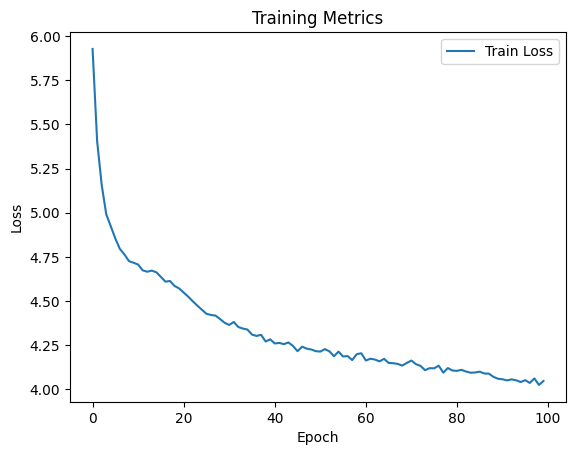

In [276]:
#plot loss for training 
import matplotlib.pyplot as plt
plt.plot(train_loss, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Metrics")
plt.legend()

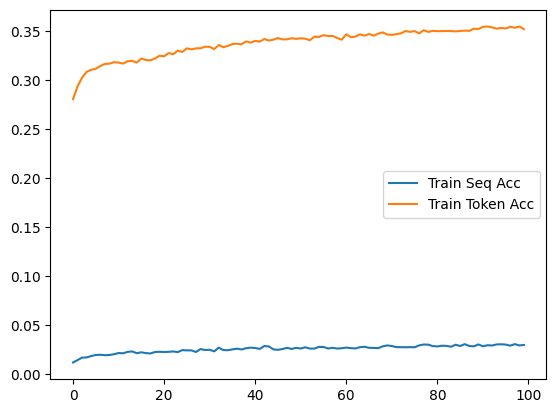

In [277]:
plt.plot(train_seq_acc, label="Train Seq Acc")
plt.plot(train_token_acc, label="Train Token Acc")
plt.legend()

In [278]:
test_loader = create_dataloader(test_df, "No_Stress", phoneme_to_id, batch_size=BATCH_SIZE, shuffle=False)
test_metrics = evaluate(das, lstm_wrapper, test_loader)
print(f"Test Loss: {test_metrics['loss']:.4f} | Test Token Acc: {test_metrics['token_acc']:.3f} | Test Seq Acc: {test_metrics['seq_acc']:.3f}")

Test Loss: 3.6588 | Test Token Acc: 0.382 | Test Seq Acc: 0.035


In [262]:
# intervention on c only and h is source
# test_loader = create_dataloader(test_df, "No_Stress", phoneme_to_id, batch_size=BATCH_SIZE, shuffle=False)
# test_metrics = evaluate(das, lstm_wrapper, test_loader)
# print(f"Test Loss: {test_metrics['loss']:.4f} | Test Token Acc: {test_metrics['token_acc']:.3f} | Test Seq Acc: {test_metrics['seq_acc']:.3f}")


Test Loss: 4.8565 | Test Token Acc: 0.305 | Test Seq Acc: 0.021


In [ ]:
# # on h only
# test_loader = create_dataloader(test_df, "No_Stress", phoneme_to_id, batch_size=BATCH_SIZE, shuffle=False)
# test_metrics = evaluate(das, lstm_wrapper, test_loader)
# print(f"Test Loss: {test_metrics['loss']:.4f} | Test Token Acc: {test_metrics['token_acc']:.3f} | Test Seq Acc: {test_metrics['seq_acc']:.3f}")


Test Loss: 6.2356 | Test Token Acc: 0.490 | Test Seq Acc: 0.010


In [ ]:
# oh both h and c 
# test_loader = create_dataloader(test_df, "No_Stress", phoneme_to_id, batch_size=BATCH_SIZE, shuffle=False)
# test_metrics = evaluate(das, lstm_wrapper, test_loader)
# print(f"Test Loss: {test_metrics['loss']:.4f} | Test Token Acc: {test_metrics['token_acc']:.3f} | Test Seq Acc: {test_metrics['seq_acc']:.3f}")



Test Loss: 4.8304 | Test Token Acc: 0.315 | Test Seq Acc: 0.021


In [ ]:
# some examples of interventions with original, base, source, type and prediction 
test_loader = create_dataloader(test_df, "No_Stress", phoneme_to_id, batch_size=BATCH_SIZE, shuffle=False)
results_df = get_results(das, lstm_wrapper, test_loader)


In [284]:
results_df[results_df["token_acc"] > 0.9]

,original,base,source,prediction,intervention_type,token_acc,seq_correct
424,"[W, IH, SH, T]","[W, AO, SH, T]","[TH, IH, JH, L]","[W, IH, SH, T]",vowel,1.0,1
450,"[W, EH, D, IH, NG]","[NG, EH, CH, IH, CH]","[W, UH, D, AY, NG]","[W, EH, D, IH, NG]",consonant,1.0,1
465,"[L, AY, ER]","[L, AA, AY]","[K, AY, ER]","[L, AY, ER]",vowel,1.0,1
480,"[AH, F, EH, N, S]","[AH, D, EH, TH, SH]","[AW, F, AA, N, S]","[AH, F, EH, N, S]",consonant,1.0,1
506,"[S, M, EH, L, D]","[S, M, EH, L, D]","[NG, S, EH, JH, B]","[S, M, EH, L, D]",vowel,1.0,1
524,"[AH, N, UW]","[IH, N, UW]","[AH, SH, UW]","[AH, N, UW]",vowel,1.0,1
528,"[F, EY, TH, S]","[F, IH, TH, S]","[W, EY, CH, TH]","[F, EY, TH, S]",vowel,1.0,1
564,"[IH, M, P, EH, R]","[IH, N, SH, EH, L]","[UH, M, P, AY, R]","[IH, M, P, EH, R]",consonant,1.0,1
597,"[B, UW, Z]","[B, EY, Z]","[N, UW, W]","[B, UW, Z]",vowel,1.0,1
612,"[D, EH, N]","[N, EH, P]","[D, ER, N]","[D, EH, N]",consonant,1.0,1


<Axes: >

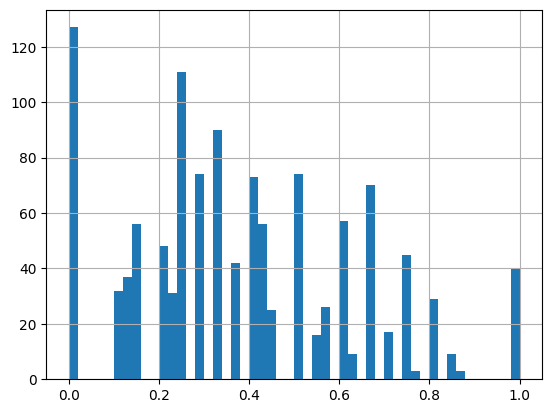

In [286]:
results_df['token_acc'].hist(bins=50)

In [293]:
results_df['seq_correct'].value_counts()

seq_correct
0    1160
1      40
Name: count, dtype: int64

In [294]:

results_df.groupby("intervention_type")["token_acc"].mean()

intervention_type
consonant    0.382419
vowel        0.385292
Name: token_acc, dtype: float64

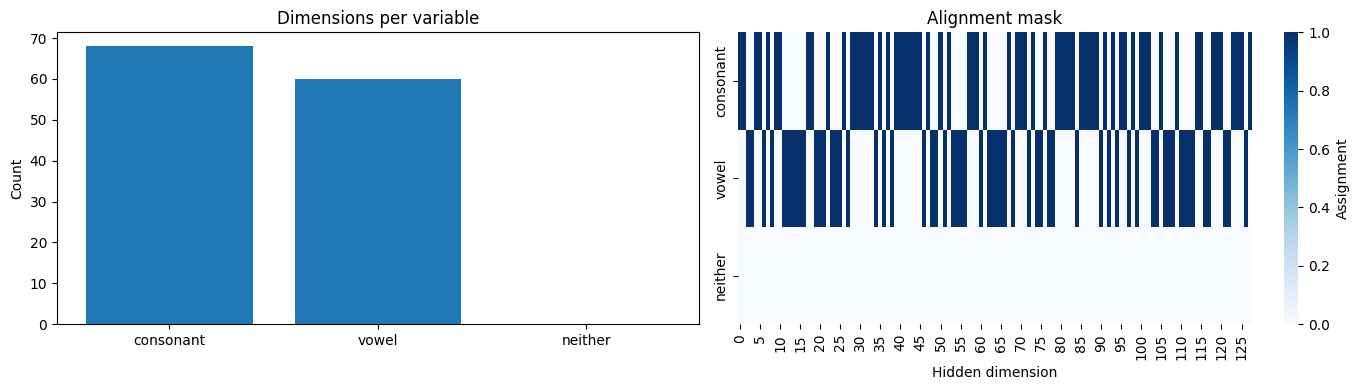

In [282]:
def plot_alignment(das: Intervention_DAS):
    """Visualize which hidden dimensions are assigned to which variable."""
    assignment = das.get_variable_assignment().cpu().numpy()
    labels = ["consonant", "vowel", "neither"]
    colors = [labels[a] for a in assignment]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Bar: how many dims per variable
    sizes = das.get_variable_sizes()
    axes[0].bar(sizes.keys(), sizes.values())
    axes[0].set_title("Dimensions per variable")
    axes[0].set_ylabel("Count")
    
    # Heatmap: alignment logits
    mask = das.get_alignment_mask().detach().cpu().numpy()
    sns.heatmap(mask.T, ax=axes[1], cmap="Blues", 
                yticklabels=labels, cbar_kws={"label": "Assignment"})
    axes[1].set_xlabel("Hidden dimension")
    axes[1].set_title("Alignment mask")
    
    plt.tight_layout()
    plt.show()

plot_alignment(das)